<a href="https://colab.research.google.com/github/livaage/nsbi-lhc-toolkit/blob/ml4hep-tifr-colab/workshops/ml4hep_tifr_colab/Exercise_2_1_visualize_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2.1 — Visualising the dataset

**Google Colab fallback.** Run the setup cell below **first** — it installs the
dependencies, pulls the `nsbi_common_utils` package plus the tutorial helpers
(`utils.py`, `generate_distributions.py`), generates the dataset, and moves into
the tutorial directory so everything below runs unchanged.

> 💡 For the training notebooks, switch to a **GPU runtime**
> (*Runtime → Change runtime type → GPU*) and consider lowering `number_of_epochs`
> / `N_TRAIN` for a quick pass.


In [2]:
# ============================================================================
# Google Colab setup — run me first.  Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/livaage/nsbi-lhc-toolkit.git"  # package + tutorial helpers
BRANCH   = "ml4hep_school_tutorial"
N_BKG, N_SIG = 300_000, 300_000     # Colab-sized dataset (raise for less MC noise in the fit)
USE_DRIVE = False                   # True -> save data/models to Google Drive so they
                                    # persist across notebooks & sessions (see notes above)
# ----------------------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = "/content/drive/MyDrive/ml4hep_tifr_colab"
    else:
        ROOT = "/content"
    os.makedirs(ROOT, exist_ok=True)
    os.chdir(ROOT)

    # 1) fetch ONLY the package source + tutorial helpers (skip Git-LFS / big blobs)
    if not os.path.isdir("nsbi-lhc-toolkit"):
        os.environ["GIT_LFS_SKIP_SMUDGE"] = "1"
        !git clone --depth 1 --filter=blob:none --sparse --branch $BRANCH $REPO_URL
        !cd nsbi-lhc-toolkit && git sparse-checkout set src workshops/ml4hep_tifr

    # 2) make `import nsbi_common_utils` work (pure-python src layout, no build step)
    src = os.path.abspath("nsbi-lhc-toolkit/src")
    if src not in sys.path:
        sys.path.insert(0, src)

    # 3) runtime deps Colab doesn't already ship (torch/jax/sklearn/... are preinstalled)
    !pip install -q pytorch-lightning onnx onnxruntime iminuit mplhep

    # 4) work from the tutorial dir so utils.py / generate_distributions.py and the
    #    ./dataframes, ./models_* relative paths resolve just like a local run
    os.chdir("nsbi-lhc-toolkit/workshops/ml4hep_tifr")

    # 5) generate the Gaussian-mixture samples if they aren't there yet
    if not os.path.exists("dataframes/signal.parquet"):
        !python generate_distributions.py --n_bkg $N_BKG --n_sig $N_SIG

print("Working dir:", os.getcwd())


Cloning into 'nsbi-lhc-toolkit'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 32 (delta 0), reused 21 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 6.51 KiB | 6.51 MiB/s, done.
fatal: unable to access 'https://github.com/livaage/nsbi-lhc-toolkit.git/': Failed to connect to github.com port 443 after 135806 ms: Connection timed out
remote: Enumerating objects: 1, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (1/1), 232 bytes | 232.00 KiB/s, done.
remote: Enumerating objects: 1, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (1/1), 1.86 KiB | 1.86 MiB/s, done.
remote: Enumerating objects: 1, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1 (delta 0), reused

Data Visualisation
---

In this notebook we look at the data we are working with. Unlike the simpler `nsbi_atlas_workshop` example (where every feature is a single Gaussian), here each sample is a **mixture of several correlated Gaussian components**. This produces multi-modal marginals and curved correlations that a single Gaussian cannot capture — a genuinely non-trivial density that is a good stress test for flexible density estimators such as Normalizing Flows.

Every sample also shares a common broad component, which guarantees overlapping support so that the density ratios we train later stay numerically well behaved. See the README for how to generate the data with `generate_distributions.py`.


In [3]:
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
hep.style.use("ATLAS")

In [4]:
BASE_PATH = "./dataframes/"

In [5]:
signal = pd.read_parquet(f"{BASE_PATH}/signal.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

### Visualising the dataset

Before training the NN, lets take a look at what the "kinematics" of the final state look like.

Note how some variables are more discriminating than others, and how several of them are **multi-modal** (more than one bump). Our goal with SBI is to use all of the variables — including their high-dimensional correlations — to build the model.


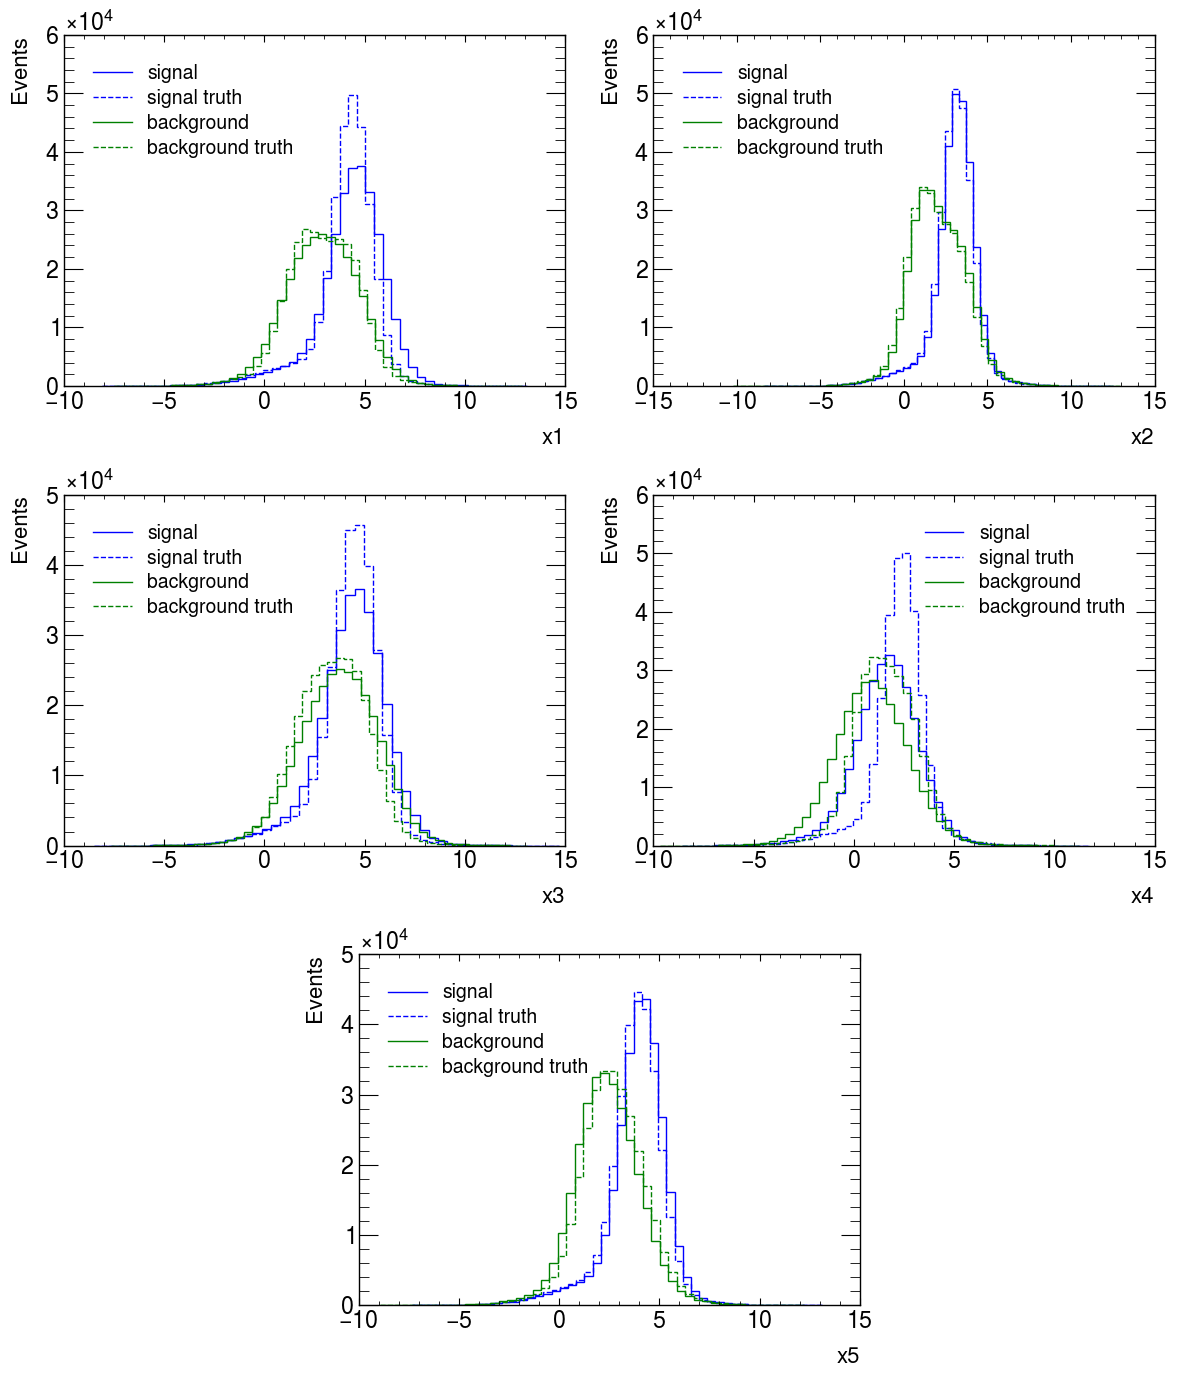

In [6]:
variables = ["x1", "x2", "x3", "x4", "x5"]
truth = ["z1", "z2", "z3", "z4", "z5"]

mosaic = [
    ["x1", "x1", "x2", "x2"],
    ["x3", "x3", "x4", "x4"],
    [".",  "x5", "x5", "."],
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(12, 14))

for var,tr in zip(variables,truth):
    ax = axes[var]

    x_sig = np.array(signal[var])
    x_sig_tr = np.array(signal[tr])
    h_sig, bins = np.histogram(x_sig, bins=50)
    h_sig_tr, bins = np.histogram(x_sig_tr, bins=50)
    hep.histplot(h_sig, bins, ax=ax, label="signal", color='blue', linewidth=1.0)
    hep.histplot(h_sig_tr, bins, ax=ax, label="signal truth", ls='--', color='blue', linewidth=1.0)

    x_bkg = np.array(background[var])
    x_bkg_tr = np.array(background[tr])
    h_bkg, bins = np.histogram(x_bkg, bins=50)
    h_bkg_tr, bins = np.histogram(x_bkg_tr, bins=50)
    hep.histplot(h_bkg, bins, ax=ax, label="background", linewidth=1.0, color="green")
    hep.histplot(h_bkg_tr, bins, ax=ax, label="background truth", ls='--', linewidth=1.0, color="green")

    ax.legend(fontsize=14)
    ax.set_xlabel(var, size=16)
    ax.set_ylabel("Events", size=16)

fig.tight_layout()